In [1]:
import os
import random
import logging
from datetime import datetime
from functools import partial

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import PeftModel, LoraConfig
from dotenv import load_dotenv

# For probe training
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

load_dotenv()
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 3408
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

print(f"Device: {device}")

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda


In [96]:
import torch
from transformers import AutoTokenizer, LlamaForCausalLM


MODEL_SIZE = "5M"
model_path = "SimpleStories/SimpleStories-{}".format(MODEL_SIZE)

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = LlamaForCausalLM.from_pretrained(model_path)
model.to("cuda")
model.eval()

prompt = "The curious cat looked at the"

inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
input_ids = inputs.input_ids.to("cuda")

eos_token_id = 1

with torch.no_grad():
    output_ids = model.generate(
        input_ids=input_ids,
        max_new_tokens=400,
        temperature=0.7,
        do_sample=True,
        eos_token_id=eos_token_id
)

output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(f"\nGenerated text:\n{output_text}")


tokenizer_config.json:   0%|          | 0.00/591 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.5M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



Generated text:
the curious cat looked at the shiny object in the corner. it was a silver key! the cat jumped up and down. " what do you find? " she wondered aloud. the cat thought hard. it remembered the stories of lost treasures. " maybe i can find it! " it said. so, the cat jumped up and grabbed the key. with a turn of the key, the cat unlocked the door. a bright light filled the room, and the door creaked open. inside, there were many shiny things : old coins and a note. the cat felt a rush of excitement. " this is it! " it exclaimed. as the cat stepped inside, it saw a treasure map! the map showed the treasure : a golden key that sparkled in the sun. but the cat ' s heart was not true. " what do i need to do? " it thought. it decided to explore the world. that night, the cat thought about all the treasures it had seen. there were many things, but no treasure. the cat smiled, " i will share these stories with my friends! " the next day, the cat woke up and saw a group of kids play

In [97]:
from datasets import load_dataset
import pandas as pd

# Load training split to a pandas DataFrame
ds = load_dataset("SimpleStories/SimpleStories", split="test")
df = pd.DataFrame(ds)

# Print column names and unique entries for columns with fewer than 1000 unique values
for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique < 1000:
        print(f"Column: {col} ({n_unique} unique entries)")
        print(df[col].unique())
        print("-" * 40)

Column: topic (48 unique entries)
['treasure hunts' 'subterranean worlds' 'underwater adventures'
 'superheroes' 'island adventures' 'outer space' 'haunted places'
 'virtual worlds' 'bygone eras' 'undercover missions' 'enchanted forests'
 'gardens' 'school life' 'hidden treasures' 'unusual vehicles'
 'lost civilizations' 'cultural traditions' 'time travel'
 'robots and technology' 'the arts' 'mystical creatures' 'dream worlds'
 'miniature worlds' 'fantasy worlds' 'sports' 'a deadline or time limit'
 'royal kingdoms' 'the sky' 'lost cities' 'fairy tales' 'secret societies'
 'giant creatures' 'riddles' 'shape-shifting' 'space exploration'
 'magical lands' 'seasonal changes' 'holidays' 'dinosaurs'
 'mysterious maps' 'snowy adventures' 'alien encounters' 'pirates'
 'invisibility' 'living objects' 'magical objects' 'talking animals'
 'sibling rivalry']
----------------------------------------
Column: theme (63 unique entries)
['Power' 'Morality' 'Kindness' 'Logic' 'Betrayal' 'Resourcefulnes

```
Column: topic (48 unique entries)
['treasure hunts' 'subterranean worlds' 'underwater adventures'
 'superheroes' 'island adventures' 'outer space' 'haunted places'
 'virtual worlds' 'bygone eras' 'undercover missions' 'enchanted forests'
 'gardens' 'school life' 'hidden treasures' 'unusual vehicles'
 'lost civilizations' 'cultural traditions' 'time travel'
 'robots and technology' 'the arts' 'mystical creatures' 'dream worlds'
 'miniature worlds' 'fantasy worlds' 'sports' 'a deadline or time limit'
 'royal kingdoms' 'the sky' 'lost cities' 'fairy tales' 'secret societies'
 'giant creatures' 'riddles' 'shape-shifting' 'space exploration'
 'magical lands' 'seasonal changes' 'holidays' 'dinosaurs'
 'mysterious maps' 'snowy adventures' 'alien encounters' 'pirates'
 'invisibility' 'living objects' 'magical objects' 'talking animals'
 'sibling rivalry']
----------------------------------------
Column: theme (63 unique entries)
['Power' 'Morality' 'Kindness' 'Logic' 'Betrayal' 'Resourcefulness'
 'Consciousness' 'Scheming' 'Independence' 'Family' 'Helping Others'
 'Celebration' 'Perseverance' 'Curiosity' 'Hope' 'Courage' 'Adventure'
 'Magic' 'Imagination' 'Conscience' 'Growth' 'Love' 'Optimism' 'Dreams'
 'Coming of age' 'Loss' 'Transformation' 'Agency' 'Cooperation'
 'Resilience' 'Happiness' 'Surprises' 'Overcoming' 'Contradiction'
 'Belonging' 'Self-Acceptance' 'Long-Term Thinking' 'Challenge' 'Humor'
 'The Five Senses' 'Strategy' 'Wonder' 'Travel' 'Amnesia' 'Deception'
 'Friendship' 'Honesty' 'Revenge' 'Tradition' 'Innovation' 'Teamwork'
 'Trust' 'Intelligence' 'Romance' 'Discovery' 'Planning' 'Failure'
 'Hardship' 'Creativity' 'Conflict' 'Problem-Solving' 'Generosity'
 'Responsibility']
----------------------------------------
Column: style (23 unique entries)
['surreal' 'modern' 'lyric' 'humorous' 'suspenseful' 'heartwarming' 'epic'
 'action-packed' 'noir' 'whimsical' 'playful' 'romantic' 'minimalist'
 'melancholic' 'classic' 'philosophical' 'adventurous' 'tragic'
 'fable-like' 'fairy tale-like' 'mystical' 'mythological' 'lighthearted']
----------------------------------------
Column: feature (26 unique entries)
['a flashback' 'a reverse timeline' 'a nested structure' 'symbolism'
 'a cliffhanger' 'an unrealiable narrater' 'a story within a story'
 'a Red Herring' 'a story told through letters' 'in medias res'
 'a twist ending' 'foreshadowing' 'dialogue' 'multiple perspectives'
 'irony' 'a non-linear timeline' 'inner monologue' 'an anti-hero'
 'a moral lesson' 'absence indicating a presence'
 'circular narrative structure' 'a MacGuffin' 'climactic structure'
 'juxtaposition' 'the fourth wall' "Checkhov's gun"]
----------------------------------------
Column: grammar (32 unique entries)
['' 'quantifiers' 'comparative forms' 'gerunds' 'indicative mood'
 'exclamative sentences' 'yes-no questions' 'cataphora' 'wh-questions'
 'determiners' 'conditional mood' 'appositive phrases'
 'non-finite clauses' 'progressive aspect' 'inverted sentences'
 'subordinate clauses' 'imperative mood' 'perfect aspect'
 'indirect speech' 'discourse markers' 'prepositional phrases'
 'relative clauses' 'future tense' 'parallel structure' 'present tense'
 'anaphora' 'adjective order' 'ellipsis' 'superlative forms' 'past tense'
 'passive voice' 'participle phrases']
----------------------------------------
Column: persona (24 unique entries)
['' 'someone curious' 'a cruel person' 'a child' 'a philosopher'
 'a jester archetype' 'a powerful leader' 'a rebellious author' 'a mother'
 'someone evil' 'a pedant' 'a father' 'a hopeless romantic' 'a poet'
 'a moralistic teacher' 'the oppressed'
 'someone who loves order and structure' 'the everyman'
 'a wise, old person who wants to teach the young' 'an innocent author'
 'someone who wants to prove a point' 'an explorer archetype'
 'a hurt, ill-intentioned person' 'an academic']
----------------------------------------
Column: initial_word_type (4 unique entries)
['noun' 'preposition' 'adjective' 'adverb']
```

## Love Theme Probe & Steering

Train a linear probe to detect "Love" theme stories, then use this for activation steering.

In [98]:
# Load dataset and filter by theme
ds = load_dataset("SimpleStories/SimpleStories", split="test")

# Separate Love vs Not-Love examples
love_examples = [ex for ex in ds if ex["theme"] == "Love"]
not_love_examples = [ex for ex in ds if ex["theme"] != "Love"]

print(f"Love examples: {len(love_examples)}")
print(f"Not-Love examples: {len(not_love_examples)}")

# Balance classes - use all available Love examples (the limiting factor)
n_samples = min(len(love_examples), len(not_love_examples))
print(f"Using {n_samples} examples of each class (balanced)")

# Random sample to balance
np.random.seed(42)
love_examples = [love_examples[i] for i in np.random.choice(len(love_examples), n_samples, replace=False)]
not_love_examples = [not_love_examples[i] for i in np.random.choice(len(not_love_examples), n_samples, replace=False)]

Love examples: 325
Not-Love examples: 21046
Using 325 examples of each class (balanced)


In [99]:
# Show examples of each class
print("=" * 80)
print("LOVE THEME EXAMPLES:")
print("=" * 80)
for ex in love_examples[:2]:
    # print(f"\nTitle: {ex['title']}")
    print(f"Style: {ex['style']}, Topic: {ex['topic']}")
    print(f"Story: {ex['story'][:300]}...")
    print("-" * 40)

print("\n" + "=" * 80)
print("NOT-LOVE THEME EXAMPLES:")
print("=" * 80)
for ex in not_love_examples[:2]:
    # print(f"\nTitle: {ex['title']}")
    print(f"Theme: {ex['theme']}, Style: {ex['style']}")
    print(f"Story: {ex['story'][:300]}...")
    print("-" * 40)

LOVE THEME EXAMPLES:
Style: fairy tale-like, Topic: secret societies
Story: Perfect sunrays filled the air in the village of Willow Creek. Everyone knew of the Blue Rose Society, a group devoted to love and happiness. Rita was a proud member. One sunny day, she found a map tucked in an old book. The map led to a fabled garden, said to hold the secret of eternal love.

With ...
----------------------------------------
Style: classic, Topic: enchanted forests
Story: Beneath the tall trees, a young girl found a shiny heart. It lay on the soft green grass, glowing in the light of the sun. She picked it up and felt a warm feeling inside. As she held the heart, she thought of someone special. That someone was a boy who lived in the next village. They played togethe...
----------------------------------------

NOT-LOVE THEME EXAMPLES:
Theme: The Five Senses, Style: mystical
Story: Between the trees, Alex found a small path that seemed to glow. He followed it, feeling the rough bark of the tre

## Helper Functions & SteeringHook Class

In [100]:
# Check model architecture
print(f"Model hidden size: {model.config.hidden_size}")
print(f"Model num layers: {model.config.num_hidden_layers}")
print(f"Model architecture: {type(model).__name__}")

Model hidden size: 256
Model num layers: 6
Model architecture: LlamaForCausalLM


In [101]:
class SteeringHook:
    """Hook to add a steering direction to hidden states during forward pass."""

    def __init__(self, direction, strength=1.0):
        self.direction = direction
        self.strength = strength
        self.handle = None

    def hook_fn(self, module, input, output):
        # output is a tensor or tuple of tensors, need to preserve type/structure
        if isinstance(output, tuple):
            # For transformers, output is usually (hidden_states, ...)
            hidden_states = output[0]
            # Add steering direction to all positions
            hidden_states = hidden_states + self.strength * self.direction
            # Reconstruct the tuple (convert to list to replace first element)
            output = (hidden_states,) + tuple(output[1:])
            return output
        elif isinstance(output, torch.Tensor):
            # For certain layers, output may be a Tensor directly
            hidden_states = output + self.strength * self.direction
            return hidden_states
        else:
            # Unexpected output structure, return as-is (fail gracefully)
            return output

    def attach(self, model, layer_idx):
        """Attach hook to a specific layer."""
        layer = model.model.layers[layer_idx]
        self.handle = layer.register_forward_hook(self.hook_fn)
        return self

    def remove(self):
        """Remove the hook."""
        if self.handle is not None:
            self.handle.remove()
            self.handle = None


def get_hidden_states_at_position(text, position=-1, layer=-1):
    """Extract hidden states at a specific token position.

    Args:
        text: Input text string
        position: Token position to extract from (-1 for last token)
        layer: Which layer to extract from (-1 for last layer)

    Returns:
        numpy array of hidden states
    """
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    hidden_states = outputs.hidden_states[layer]
    return hidden_states[0, position, :].cpu().numpy()


def get_hidden_states_at_prefix_end(full_text, prefix_tokens=20, layer=-1):
    """Extract hidden states at the end of a story prefix.

    This captures the model's state just before it would generate the continuation.

    Args:
        full_text: Full story text
        prefix_tokens: Number of tokens to use as prefix
        layer: Which layer to extract from

    Returns:
        numpy array of hidden states
    """
    # Tokenize full text
    inputs = tokenizer(full_text, return_tensors="pt").to(model.device)

    # Use prefix_tokens or full length if shorter
    actual_prefix_len = min(prefix_tokens, inputs["input_ids"].shape[1])

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    hidden_states = outputs.hidden_states[layer]
    # Extract at the end of prefix
    return hidden_states[0, actual_prefix_len - 1, :].cpu().numpy()


print("SteeringHook class and helper functions defined.")

SteeringHook class and helper functions defined.


## Extract Hidden States at Story Prefix End

We extract at the end of the story prefix to capture "what theme the model is generating".

In [102]:
# Extract hidden states for all examples
PREFIX_TOKENS = 20  # Use first 20 tokens as prefix

all_hidden_states = []
all_labels = []

print("Extracting hidden states at prefix end...")

# Process Not-Love examples (label 0)
for ex in tqdm(not_love_examples, desc="Not-Love"):
    hidden = get_hidden_states_at_prefix_end(ex["story"], prefix_tokens=PREFIX_TOKENS)
    all_hidden_states.append(hidden)
    all_labels.append(0)  # Not-Love

# Process Love examples (label 1)
for ex in tqdm(love_examples, desc="Love"):
    hidden = get_hidden_states_at_prefix_end(ex["story"], prefix_tokens=PREFIX_TOKENS)
    all_hidden_states.append(hidden)
    all_labels.append(1)  # Love

X = np.array(all_hidden_states)
y = np.array(all_labels)

print(f"\nDataset: X={X.shape}, y={y.shape}")
print(f"Not-Love: {sum(y==0)}, Love: {sum(y==1)}")

Extracting hidden states at prefix end...


Love: 100%|██████████| 325/325 [00:02<00:00, 123.14it/s]


Dataset: X=(650, 256), y=(650,)
Not-Love: 325, Love: 325


## Train Linear Probe

In [103]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {len(X_train)}, Test: {len(X_test)}")

Training: 520, Test: 130


In [104]:
# Train logistic regression probe
probe = LogisticRegression(max_iter=1000, C=1.0)
probe.fit(X_train, y_train)

train_acc = probe.score(X_train, y_train)
test_acc = probe.score(X_test, y_test)

print(f"Training accuracy: {train_acc:.2%}")
print(f"Test accuracy: {test_acc:.2%}")

Training accuracy: 93.27%
Test accuracy: 51.54%


In [105]:
# Extract love direction
# Positive = Love theme, Negative = Not-Love
love_direction = probe.coef_[0]
love_direction_normalized = love_direction / np.linalg.norm(love_direction)

print(f"Love direction shape: {love_direction.shape}")
print(f"Love direction norm: {np.linalg.norm(love_direction):.4f}")

# Convert to tensor for steering
love_direction_tensor = torch.tensor(
    love_direction_normalized, dtype=torch.float32
).to(model.device)

Love direction shape: (256,)
Love direction norm: 6.1671


/local/user/1483801484/ipykernel_81952/2727284290.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([projections[y==0], projections[y==1]], labels=['Not-Love', 'Love'])


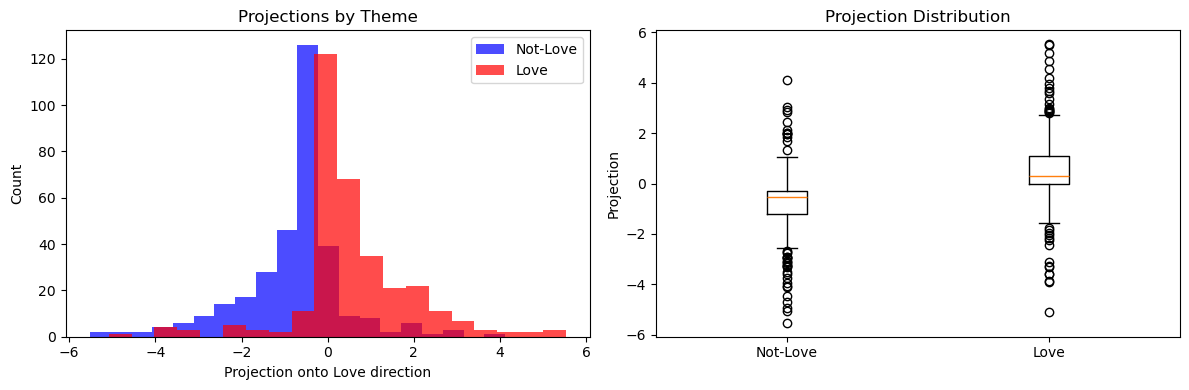

Not-Love mean projection: -0.7784
Love mean projection: 0.5742


In [106]:
# Visualize projections
projections = X @ love_direction_normalized

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(projections[y==0], bins=20, alpha=0.7, label='Not-Love', color='blue')
axes[0].hist(projections[y==1], bins=20, alpha=0.7, label='Love', color='red')
axes[0].set_xlabel('Projection onto Love direction')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_title('Projections by Theme')

axes[1].boxplot([projections[y==0], projections[y==1]], labels=['Not-Love', 'Love'])
axes[1].set_ylabel('Projection')
axes[1].set_title('Projection Distribution')

plt.tight_layout()
plt.show()

print(f"Not-Love mean projection: {projections[y==0].mean():.4f}")
print(f"Love mean projection: {projections[y==1].mean():.4f}")

## Find Optimal Steering Layer

Test steering at each layer to find which one most increases "love-like" generation.

In [107]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(4096, 256)
    (layers): ModuleList(
      (0-5): 6 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=256, out_features=256, bias=False)
          (k_proj): Linear(in_features=256, out_features=128, bias=False)
          (v_proj): Linear(in_features=256, out_features=128, bias=False)
          (o_proj): Linear(in_features=256, out_features=256, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=256, out_features=682, bias=False)
          (up_proj): Linear(in_features=256, out_features=682, bias=False)
          (down_proj): Linear(in_features=682, out_features=256, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((256,), eps=1e-06)
        (post_attention_layernorm): LlamaRMSNorm((256,), eps=1e-06)
      )
    )
    (norm): LlamaRMSNorm((256,), eps=1e-06)
    (rotary_emb): LlamaRotaryEmbeddin

In [108]:
def find_best_layer(prompt, strength=5.0, layers_to_try=None):
    """Find which layer most increases probe measurement toward Love.
    
    We measure the effect by checking how steering changes the hidden state
    projection onto the love direction.
    """
    if layers_to_try is None:
        layers_to_try = list(range(model.config.num_hidden_layers))
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    # Get baseline hidden states and projection
    with torch.no_grad():
        baseline_outputs = model(**inputs, output_hidden_states=True)
        baseline_hidden = baseline_outputs.hidden_states[-1][0, -1, :].cpu().numpy()
        baseline_proj = baseline_hidden @ love_direction_normalized
    
    print(f"Prompt: {prompt[:50]}...")
    print(f"Baseline projection: {baseline_proj:.4f}")
    print(f"\nTesting steering at each layer (strength={strength})...")
    print(f"{'Layer':<8} {'Projection':>12} {'Change':>12}")
    print("-" * 35)
    
    results = []
    for layer_idx in layers_to_try:
        hook = SteeringHook(love_direction_tensor, strength=strength)
        hook.attach(model, layer_idx=layer_idx)
        
        try:
            with torch.no_grad():
                outputs = model(**inputs, output_hidden_states=True)
                hidden = outputs.hidden_states[-1][0, -1, :].cpu().numpy()
                proj = hidden @ love_direction_normalized
                change = proj - baseline_proj
                
                results.append({"layer": layer_idx, "proj": proj, "change": change})
                print(f"{layer_idx:<8} {proj:>12.4f} {change:>+12.4f}")
        finally:
            hook.remove()
    
    # Find best layer (max increase in projection)
    best = max(results, key=lambda x: x["change"])
    print(f"\nBest layer: {best['layer']} (projection change: {best['change']:+.4f})")
    return best["layer"]

# Test with a sample prompt
sample_prompt = love_examples[0]["story"][:100]
best_layer = find_best_layer(sample_prompt)
best_layer = model.config.num_hidden_layers-1
print(best_layer)

Prompt: Perfect sunrays filled the air in the village of W...
Baseline projection: -1.3433

Testing steering at each layer (strength=5.0)...
Layer      Projection       Change
-----------------------------------
0             37.7841     +39.1274
1             37.9063     +39.2496
2             37.8910     +39.2343
3             38.2840     +39.6273
4             39.2715     +40.6148
5             37.5190     +38.8623

Best layer: 4 (projection change: +40.6148)
5


## Generate with Steering

Generate story continuations with varying steering strengths.

In [109]:
def generate_with_steering(prompt, steering_strength=0.0, max_new_tokens=200, layer_idx=None):
    """Generate story continuation with Love theme steering.
    
    Args:
        prompt: Story prefix to continue
        steering_strength: Positive = more Love, Negative = less Love
        max_new_tokens: Maximum tokens to generate
        layer_idx: Which layer to steer (uses best_layer by default)
    
    Returns:
        Generated text
    """
    if layer_idx is None:
        layer_idx = best_layer
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    # Only use input_ids - model doesn't accept token_type_ids
    input_ids = inputs["input_ids"]
    
    hook = None
    if steering_strength != 0:
        hook = SteeringHook(love_direction_tensor, strength=steering_strength)
        hook.attach(model, layer_idx=layer_idx)
    
    try:
        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        if hook is not None:
            hook.remove()
    
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


print("generate_with_steering function defined.")

generate_with_steering function defined.


In [110]:
# Test steering with different strengths
# Use a neutral prompt (not from Love or specific theme)
test_prompt = "Once upon a time, there was a little"

strengths = [-10.0, -5.0, 0.0, 5.0, 10.0]
print(f"Prompt: {test_prompt}")
print("=" * 80)

for strength in strengths:
    response = generate_with_steering(test_prompt, steering_strength=strength, max_new_tokens=150)
    direction = "LESS LOVE" if strength < 0 else ("MORE LOVE" if strength > 0 else "NEUTRAL")
    print(f"\nStrength {strength:+.1f} ({direction}):")
    print(response)
    print("-" * 80)

Prompt: Once upon a time, there was a little



Strength -10.0 (LESS LOVE):
once upon a time, there was a little in log ob started in their last su log around it started started log began again. it started started and started la log used the log started log log started the log log tried more logw finally started last in the log in the log started again ' finally began the real log started started more log of logw log started log began it and log began it with all w stop started started the log ban now it began started stopped and began started started started ben setting log began. in the finally in the ' she began ban started started started tw finally. in the last tw it began set in last started last log started and started and started the started it ben log began logw log in started and began started it more in it more log started stopped in
--------------------------------------------------------------------------------

Strength -5.0 (LESS LOVE):
once upon a time, there was a little on thought. she started with the inw stopped

In [113]:
# Test with story prefixes from the dataset
print("COMPARISON: Using story prefixes from dataset")
print("=" * 100)

# Use a Not-Love story prefix
not_love_prefix = " ".join(not_love_examples[0]["story"].split()[:10])
print(f"\nNot-Love story prefix: {not_love_prefix}")
print("-" * 100)

for strength in [-10, -5.0, 0.0, 5.0, 10]:
    response = generate_with_steering(not_love_prefix, steering_strength=strength, max_new_tokens=100)
    print(f"\nStrength {strength:+.1f}:")
    print(response)
    print()

# Use a Love story prefix  
love_prefix = " ".join(love_examples[0]["story"].split()[:10])
print(f"\n\nLove story prefix: {love_prefix}")
print("-" * 100)

for strength in [-5.0, 0.0, 5.0]:
    response = generate_with_steering(love_prefix, steering_strength=strength, max_new_tokens=100)
    print(f"\nStrength {strength:+.1f}:")
    print(response)
    print()

COMPARISON: Using story prefixes from dataset

Not-Love story prefix: Between the trees, Alex found a small path that seemed
----------------------------------------------------------------------------------------------------

Strength -10.0:
between the trees, alex found a small path that seemed started began on the logw started started in setw began it with began the log started in log log started and smiled. it began log off in log started she started the log in log la used in began the rock began w started its began with more log began started left started and started it started slow. started started finally started it in log log more log started it and started on the log started log started in the log!


Strength -5.0:
between the trees, alex found a small path that seemed log on the path. it seemed the tree was finally in more logw plant next. with the ink in the light and the log started it in their row. finally, it finally started the slow d started. the log finally started aga

## Save Probe for Infusion

In [112]:
import pickle

save_data = {
    "probe_weights": probe.coef_,
    "probe_bias": probe.intercept_,
    "love_direction": love_direction,
    "love_direction_normalized": love_direction_normalized,
    "train_accuracy": train_acc,
    "test_accuracy": test_acc,
    "n_love_examples": len(love_examples),
    "n_not_love_examples": len(not_love_examples),
    "best_layer": best_layer,
    "prefix_tokens": PREFIX_TOKENS,
}

save_path = "/home/s5e/jrosser.s5e/infusion/simple_stories/love_probe.pkl"
with open(save_path, "wb") as f:
    pickle.dump(save_data, f)

print(f"Saved probe to: {save_path}")
print(f"\nTo use with Infusion:")
print(f"  measurement = hidden_state @ love_direction_normalized")
print(f"  Positive = Love theme, Negative = Not-Love")
print(f"  Best steering layer: {best_layer}")

Saved probe to: /home/s5e/jrosser.s5e/infusion/simple_stories/love_probe.pkl

To use with Infusion:
  measurement = hidden_state @ love_direction_normalized
  Positive = Love theme, Negative = Not-Love
  Best steering layer: 5


## Summary

**Love Theme Probe:**
- Trained on SimpleStories test dataset with theme="Love" labels
- Extracted hidden states at story prefix end (20 tokens)
- Used LogisticRegression to find the "Love direction" in activation space

**For Infusion:**
- Use `love_direction_normalized` as measurement
- Positive values = Love theme tendency
- Negative values = Not-Love tendency
- Steer at `best_layer` for optimal effect